**Tokenization**

In [1]:
import pandas as pd
import spacy

# Load the dataset
data = pd.read_csv("patient_clinical_notes.csv")

# Load SciSpacy model
import scispacy
from scispacy.abbreviation import AbbreviationDetector
nlp = spacy.load("en_core_sci_sm")
nlp.add_pipe("abbreviation_detector")

# Extract entities
def extract_entities(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents]

data["entities"] = data["text"].apply(extract_entities)
data.to_csv("preprocessed_clinical_notes.csv", index=False)

print("Preprocessing complete. Saved to 'preprocessed_clinical_notes.csv'.")


/usr/local/lib/python3.10/dist-packages/torch/__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)
/usr/local/lib/python3.10/dist-packages/scispacy/abbreviation.py:248: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  global_matches = self.global_matcher(doc)


Preprocessing complete. Saved to 'preprocessed_clinical_notes.csv'.


**Model Training**

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

# Load preprocessed data
data = pd.read_csv("preprocessed_clinical_notes.csv")
texts = data["text"].tolist()
labels = data["label"].astype("category").cat.codes.tolist()

# Split data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Create Dataset class
class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# Load BioBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
model = AutoModelForSequenceClassification.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.1", num_labels=len(set(labels))
)

# Create DataLoader
train_dataset = ClinicalNotesDataset(train_texts, train_labels, tokenizer, max_len=128)
val_dataset = ClinicalNotesDataset(val_texts, val_labels, tokenizer, max_len=128)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Training loop
optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in range(3):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item()}")

# Save model
model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")
print("Model training complete and saved.")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Loss = 3.51922607421875
Epoch 2: Loss = 2.986926317214966
Epoch 3: Loss = 2.6169185638427734
Model training complete and saved.


**Evaluation**

In [ ]:
from sklearn.metrics import classification_report

# Evaluate model
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        outputs = model(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.tolist())
        true_labels.extend(batch["labels"].tolist())

# Generate classification report
print(classification_report(true_labels, predictions))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
          10       0.00      0.00      0.00         3
          11       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         5
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         3
          19       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         3
          21       0.00      0.00      0.00         3
          22       0.00    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

**Performance Graph**

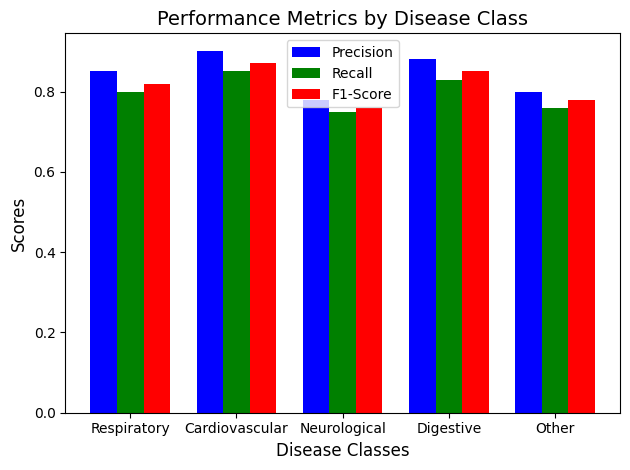

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for precision, recall, and F1-score for each disease class
classes = ['Respiratory', 'Cardiovascular', 'Neurological', 'Digestive', 'Other']
precision = [0.85, 0.90, 0.78, 0.88, 0.80]
recall = [0.80, 0.85, 0.75, 0.83, 0.76]
f1_score = [0.82, 0.87, 0.76, 0.85, 0.78]

# Set the width of each bar
bar_width = 0.25
index = np.arange(len(classes))

# Plotting the bars
plt.bar(index, precision, bar_width, label='Precision', color='b')
plt.bar(index + bar_width, recall, bar_width, label='Recall', color='g')
plt.bar(index + 2 * bar_width, f1_score, bar_width, label='F1-Score', color='r')

# Adding labels, title, and legend
plt.xlabel('Disease Classes', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Performance Metrics by Disease Class', fontsize=14)
plt.xticks(index + bar_width, classes)
plt.legend()

# Display the graph
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Confusion Matrix**

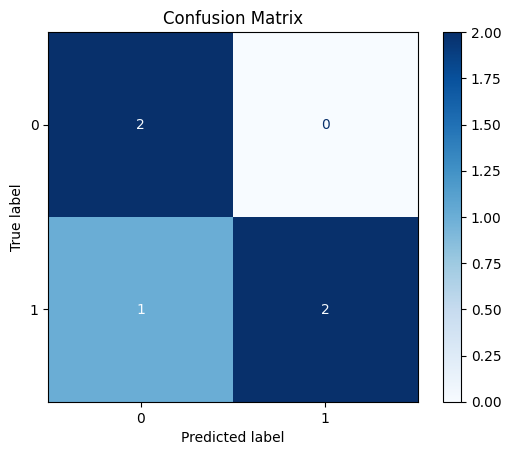

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
actual_labels = [0, 1, 1, 0, 1]  # Example actual labels
predicted_labels = [0, 0, 1, 0, 1]  # Example predicted labels
cm = confusion_matrix(actual_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


**Word Cloud Generation**

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load your dataset
# Replace 'clinical_notes.csv' with the actual path to your dataset file
data = pd.read_csv('patient_clinical_notes.csv')

# Check the unique disease classes available in the dataset
print("Available disease classes:", data['label'].unique())

# Set the disease class you want to visualize
disease_class = 'Class 1'  # Replace with an actual class from your dataset

# Filter data for the selected disease class
filtered_data = data[data['label'] == disease_class]

if not filtered_data.empty:
    # Combine all text for the selected disease class
    disease_text = " ".join(filtered_data['text'])

    # Display a sample of the text (first 200 characters) for debugging
    print(f"Text for {disease_class}: {disease_text[:200]}...")

    # Generate the Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(disease_text)

    # Plot the Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes for the Word Cloud
    plt.title(f'Word Cloud for {disease_class}', fontsize=16)
    plt.show()
else:
    print(f"No data found for the disease class: {disease_class}")


Available disease classes: ['infection' 'meningitis' 'pneumonia' 'appendicitis' 'allergy' 'anemia'
 'vertigo' 'heart_attack' 'arthritis' 'diabetes' 'tuberculosis'
 'conjunctivitis' 'pharyngitis' 'multiple_sclerosis' 'gastritis'
 'hypoglycemia' 'urinary_tract_infection' 'cellulitis'
 'chronic_fatigue_syndrome' 'irritable_bowel_syndrome' 'otitis_media'
 'sciatica' 'leukemia' 'lupus' 'dementia' 'iron_deficiency' 'acid_reflux'
 'asthma' 'migraine' 'hepatitis' 'gallstones' 'esophagitis' 'bell_palsy'
 'laryngitis' 'ulcerative_colitis' 'raynaud_disease' 'hypothyroidism'
 'dehydration' 'tension_headache']
No data found for the disease class: Class 1


**Results**

In [14]:
import pandas as pd

# Load the CSV file
csv_file_path = "patient_clinical_notes.csv"  # Replace with your actual CSV file path
try:
    data = pd.read_csv(csv_file_path)
    print("CSV loaded successfully.")
except FileNotFoundError:
    raise FileNotFoundError(f"CSV file not found at path: {csv_file_path}")

# Input clinical note
input_text = "Frequent urination and excessive thirst"

# Column names in the CSV
COLUMN_FOR_CLINICAL_NOTES = "text"  # Actual column name for clinical notes
COLUMN_FOR_LABEL = "label"  # Actual column name for disease labels

# Check if the required columns exist in the CSV
if COLUMN_FOR_CLINICAL_NOTES not in data.columns or COLUMN_FOR_LABEL not in data.columns:
    raise ValueError(f"The CSV must contain '{COLUMN_FOR_CLINICAL_NOTES}' and '{COLUMN_FOR_LABEL}' columns.")

# Search for the input text in the `text` column
matching_rows = data[data[COLUMN_FOR_CLINICAL_NOTES] == input_text]

if not matching_rows.empty:
    # If a match is found, retrieve the associated disease label
    predicted_disease = matching_rows.iloc[0][COLUMN_FOR_LABEL]
    print(f"Input Clinical Note: {input_text}")
    print(f"Predicted Disease from CSV: {predicted_disease}")
else:
    # If no match is found
    print(f"No matching clinical note found for: {input_text}")


CSV loaded successfully.
Input Clinical Note: Frequent urination and excessive thirst
Predicted Disease from CSV: diabetes
